# Plotting strait transports and strait topography in ACCESS-OM3 and ACCESS-OM2

Based on https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/strait_transports/strait_transports.ipynb

Related issues
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/16
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/41
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/1

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
import os
if not papermill: 
    import nci_ipynb  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
import intake
from dask.distributed import Client
import matplotlib.pyplot as plt
import cmocean as cm
import cftime
import numpy as np
import xarray as xr

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33071 instead
  warnings.warn(


/proxy/33071/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33071/status,
Dashboard: /proxy/33071/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42417,Workers: 0
Dashboard: /proxy/33071/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45479,Total threads: 1
Dashboard: /proxy/46849/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:45375,


In [6]:
plotmaps = False  # whether to plot maps and transects of all straits

In [7]:
IAF = esm_file.find('iaf') > 0
IAF

True

## Define strait names, locations and obs

In [8]:
# Strait locations for ACCESS-OM3: [minlon, maxlon, minlat, maxlat]
# Add as many as you like, but they must be zonal or meridional
om3straits = {
    '25km': {
            'Makassar Strait':     [115-360, 119.5-360,  -2.87, -2.87],  # INSTANT, Gordon et al. 2008 http://dx.doi.org/10.1029/2008GL036372
            'Lifamatola Passage':  [124.5-360, 127.9-360,  -1.6, -1.6],  # NB: significantly shifted from obs to span resolved land INSTANT, van Aken et al. (2009) http://dx.doi.org/10.1016/j.dsr.2009.02.001
            'Lombok Strait':       [-244.8, -243.5,  -8.5, -8.5],
            'Ombai Strait':        [-235.0, -235.0,  -9.21, -8.3],
            'Timor Strait':        [123-360, 123-360, -11.7, -10.7],
            'Timor Strait (full)': [123-360, 123-360, -17.5, -10.7],
            'Leti Strait':         [127-360, 130-360, -8.4, -8.4],
            'Karimata Strait':     [112-360, 112-360, -7.25, -3],
            'ITF South':           [114-360, 138-360, -8.2, -8.2],
            'ITF North':           [115-360, 133-360,  -2.87, -2.87],
            'Torres Strait':       [142.5-360, 142.5-360, -12, -8],
            'Drake Passage':       [-69.9,   -69.9,  -71.6, -51.0],
            'Bering Strait':       [-172,     -167,   65.8,  65.8],
            'Denmark Strait':      [-42,       -22,   65.8,  65.8],
            'East Taiwan Channel': [-238.3,   -236,   24.4,  24.4],  # WOCE PCM-1 array between Taiwan and Iriomote, JohnsLeeZhangZantoppLiuYang2001a http://dx.doi.org/10.1175/1520-0485(2001)031<1031:TKEOTM>2.0.CO;2
            'Florida Current':     [-81,     -78.8,   26.7,  26.7],  # MeinenBaringerGarcia2010a http://dx.doi.org/10.1016/j.dsr.2010.04.001
            'Bosphorus':           [28.5, 29.2, 41.15, 41.15],
            'Gibraltar':           [-5.5, -5.5, 35.5, 36.5, ],
            'Labrador-Greenland, 60°N': [-64.5, -44, 60, 60],  # Sort-of OSNAP-West
            'Greenland-Norway, 60°N': [-44, 8, 60, 60],  # Sort-of OSNAP-East
            },
}
for model, straits in om3straits.items(): 
    for strait, (minlon, maxlon, minlat, maxlat) in straits.items():
        if (minlon != maxlon) and (minlat != maxlat):
            raise ValueError(f'Error in {model} {strait}: Must have either minlon == maxlon or minlat == maxlat')

In [9]:
# Strait locations for ACCESS-OM2: [minlon, maxlon, minlat, maxlat]
# Add as many as you like, but they must be zonal or meridional
om2straits = {
    '1deg': {
            'Lombok Strait': [-245, -242, -8.33, -8.33],
            'Ombai Strait':  [-237, -237, -10.33, -8.33],
            'Timor Strait':  [-233, -233, -13.9, -9],
            'Drake Passage': [-69.9, -69.9, -71.6, -51.0],
            'North Atlantic, 60°N': [-64, 8, 60, 60],  # Sort-of OSNAP
            'Labrador-Greenland, 60°N': [-64, -44, 60, 60],  # Sort-of OSNAP-West
            'Greenland-Norway, 60°N': [-44, 8, 60, 60],  # Sort-of OSNAP-East
            'East Taiwan Channel':[121.7-360, 125-360, 24.4, 24.4],  # xmax extended by 1deg as in TsengLinChenThompsonBentsenBoningBozecCassouChassignet2016a
            'Florida Current':[-81, -77.8, 26.7, 26.7], # xmax extended  # MeinenBaringerGarcia2010a
            },
    '025deg': {
            'Makassar Strait':     [115-360, 119.5-360,  -2.87, -2.87],  # INSTANT, Gordon et al 2008 http://dx.doi.org/10.1029/2008GL036372
            'Lifamatola Passage':  [125-360, 127.7-360,  -1.7,  -1.7],  # NB: significantly shifted from obs to span resolved land INSTANT, van Aken et al. (2009) http://dx.doi.org/10.1016/j.dsr.2009.02.001
            'Lombok Strait':       [-244.7, -243.6, -8.22, -8.22],
            'Ombai Strait':        [-235.5, -235.5, -9.21, -8.47],
            'Timor Strait':        [123-360, 123-360, -11.7, -10.8],  # to match OSNAP; was previously [-233, -233, -13.86, -8.71]
            'Timor Strait (full)': [123-360, 123-360, -17.5, -10.8],  # to match OSNAP; was previously [-233, -233, -13.86, -8.71]
            'Leti Strait':         [127-360, 130-360, -8.4, -8.4],
            'Karimata Strait':     [112-360, 112-360, -7.25, -3],
            'ITF South':           [114-360, 138-360, -8.2, -8.2],
            'ITF North':           [115-360, 133-360,  -2.87, -2.87],
            'Torres Strait':       [142.5-360, 142.5-360, -12, -8],
            'Drake Passage':       [-69.9, -69.9, -71.6, -51.0],
            'Bering Strait':       [-172,     -167,   65.8,  65.8],
            'Denmark Strait':      [-42,       -22,   65.8,  65.8],
            'North Atlantic, 60°N': [-64.5, 8, 60, 60],  # Sort-of OSNAP
            'Labrador-Greenland, 60°N': [-64.5, -44, 60, 60],  # Sort-of OSNAP-West
            'Greenland-Norway, 60°N': [-44, 8, 60, 60],  # Sort-of OSNAP-East
            'East Taiwan Channel': [121.7-360, 124-360, 24.4, 24.4],  # WOCE PCM-1 array between Taiwan and Iriomote (JohnsLeeZhangZantoppLiuYang2001a)
            'Florida Current':     [-81, -78.8, 26.7, 26.7],  # MeinenBaringerGarcia2010a
            'Bosphorus':           [28.5, 29.5, 41.15, 41.15],
            'Gibraltar':           [-5.5, -5.5, 35.5, 36.5, ],
            },
    '01deg': {
            'Lombok Strait': [-244.3, -243.8, -8.37, -8.37],
            'Ombai Strait':  [-234.9, -234.9, -8.86, -8.27],
            'Timor Strait':  [-232.6, -232.6, -13.96, -8.37],
            'Drake Passage': [-69.9, -69.9, -71.6, -51.0],
            'Bering Strait': [-172, -167, 65.8, 65.8],
            'Denmark Strait':[-42, -22, 65.8, 65.8],
            'North Atlantic, 60°N': [-64.5, 8, 60, 60],  # Sort-of OSNAP
            'Labrador-Greenland, 60°N': [-64.5, -44, 60, 60],  # Sort-of OSNAP-West
            'Greenland-Norway, 60°N': [-44, 8, 60, 60],  # Sort-of OSNAP-East
            'East Taiwan Channel':[121.7-360, 124-360, 24.4, 24.4],  # WOCE PCM-1 array between Taiwan and Iriomote (JohnsLeeZhangZantoppLiuYang2001a)
            'Florida Current':[-81, -78.8, 26.7, 26.7],  # MeinenBaringerGarcia2010a
            },
}
for model, straits in om2straits.items(): 
    for strait, (minlon, maxlon, minlat, maxlat) in straits.items():
        if (minlon != maxlon) and (minlat != maxlat):
            raise ValueError(f'Error in {model} {strait}: Must have either minlon == maxlon or minlat == maxlat')

In [10]:
def date(y, m, d):
    return cftime.DatetimeProlepticGregorian(y, m, d)

In [11]:
obs = {  # observed transport (Sv)
# Also see table 3 in GutjahrETAL2019a http://dx.doi.org/10.5194/gmd-12-3241-2019
# table 1 in YangCessi2024a http://dx.doi.org/10.1029/2024JC021463
# TODO: use uncertainties from Gordon et al (2010) p121 for IAF? Seem handwavy? do we want uncertainty or stdev?
            'Makassar Strait': {'Gordon et al. (2008)': {'value': -11.6, 'lo': -11.6-3.3, 'hi':  -11.6+3.3, 'time': [date(2004, 1, 18), date(2006,  11, 27)]}},  # INSTANT, GordonSusantoFfieldHuberPranowoWirasantosa2008a http://dx.doi.org/10.1029/2008GL036372
            # 'Lifamatola Passage': {'van Aken et al. (2009)': {'value': 1.3-2.7, 'lo': (1.3-2.7)-(1.1+1.3), 'hi': (1.3-2.7)+(1.1+1.3), 'time': [date(2004, 1, 26), date(2006,  12, 4)]}},  # combining below and above 1250m; range is 1std assuming 100% correlation; INSTANT, VanAkenBrodjonegoroJaya2009a http://dx.doi.org/10.1016/j.dsr.2009.02.001
            'Lifamatola Passage': {'Gordon et al. (2010)': {'value': 1.4-2.5, 'lo': (1.4-2.5)-1.4*0.5-2.5*0.05, 'hi': (1.4-2.5)+1.4*0.5+2.5*0.05, 'time': [date(2004, 1, 26), date(2006,  12, 4)]}},  # combining below and above 1250m; range is uncertainty from p121 assuming 100% correlation; INSTANT, GordonETAL2010a http://dx.doi.org/10.1016/j.dynatmoce.2009.12.002; also see VanAkenBrodjonegoroJaya2009a http://dx.doi.org/10.1016/j.dsr.2009.02.001
            'Lombok Strait': {'Sprintall et al. (2009)': {'value': -2.6, 'lo': -1.8, 'hi':  -3.2, 'time': [date(2004, 1, 10), date(2005,  6, 15)], 'depth': [0,  300]}},  # time=dates with both moorings; INSTANT, SprintallWijffelsMolcardJaya2009a http://dx.doi.org/10.1029/2008JC005257
            'Ombai Strait':  {'Sprintall et al. (2009)': {'value': -4.9, 'lo': -2.7, 'hi':  -5.0, 'time': [date(2004, 1,  4), date(2006, 12,  6)], 'depth': [0, 1200]}},  # time=dates with both moorings; INSTANT, SprintallWijffelsMolcardJaya2009a http://dx.doi.org/10.1029/2008JC005257
            'Timor Strait':  {'Sprintall et al. (2009)': {'value': -7.5, 'lo': -6.2, 'hi': -10.5, 'time': [date(2004, 1,  1), date(2006, 12, 12)], 'depth': [0, 1890]}},  # time=dates with  all moorings; INSTANT, SprintallWijffelsMolcardJaya2009a http://dx.doi.org/10.1029/2008JC005257
            'Drake Passage': {'Donohue et al. (2016)': {'value': 173.3, 'lo': 173.3-10.7, 'hi': 173.3+10.7, 'time': [date(2007, 11, 10), date(2011, 11, 10)]}},  # day of month is a guess! DonohueTraceyWattsChidichimoChereskin2016a http://dx.doi.org/10.1002/2016GL070319
            'Bering Strait': {'Woodgate (2018)': {'value': 1, 'lo': 0.7, 'hi': 1.2, 'time': [date(2000, 1,  1), date(2015, 1, 1)]}},  # rough climatology for 2000s; was ~0.8Sv prior to that - Woodgate2018a http://dx.doi.org/10.1016/j.pocean.2017.12.007
            # 'Denmark Strait':  {},
            'East Taiwan Channel': {'Johns et al. (2001)': {'value': 21.5, 'lo': 21.5-2.5, 'hi': 21.5+2.5, 'time': [date(1994, 9,  1), date(1996, 5, 1)]}},  # WOCE PCM-1 array between Taiwan and Iriomote, JohnsLeeZhangZantoppLiuYang2001a http://dx.doi.org/10.1175/1520-0485(2001)031<1031:TKEOTM>2.0.CO;2
            'Florida Current': {'Meinen et al. (2010)': {'value': 32.1, 'lo': 32.1-3.3, 'hi': 32.1+3.3, 'time': [date(1982, 1,  1), date(2008, 1, 1)]}},  # range is ±1SD; rough dates from fig2 MeinenBaringerGarcia2010a http://dx.doi.org/10.1016/j.dsr.2010.04.001
            # 'Bosphorus':  {},
            # 'Gibraltar': {},
}


## Load GEBCO

In [12]:
gebco = xr.open_dataset('/g/data/ik11/inputs/GEBCO_2024/GEBCO_2024.nc',
                        chunks='auto')['elevation']

In [13]:
def glon(lon):
    """
    Convert MOM longitude (-270 - 90) to GEBCO longitude (-180 - 180)
    """
    if lon < -180:
        return lon+360
    else:
        return lon

In [14]:
def mlon(lon):
    """
    Convert GEBCO longitude (-180 - 180) to MOM longitude (-270 - 90) 
    """
    if lon > 90:
        return lon-360
    else:
        return lon

## Load ACCESS-OM3 data from ESM datastore

In [15]:
catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json',
                '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
            ]
catalogs

['/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json']

In [16]:
datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
datastores

{'25km-iaf-test-for-AK-expt-7df5ef4c': <datastore catalog with 17 dataset(s) from 5019 asset(s)>,
 'MC_25km_jra_iaf-1.0-beta-5165c0f8': <datastore catalog with 22 dataset(s) from 6042 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415': <datastore catalog with 24 dataset(s) from 16791 asset(s)>}

In [17]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
om3exptname

'MC_25km_jra_iaf+wombatlite-test3v2-00532b88'

## Load OM3 data

In [18]:
om3varnames = [ 'umo_2d', 'vmo_2d', 'uo', 'vo', 'deptho' ]

om3staticvarnames = [ 'deptho' ]  # workaround - see below

om3vars = {
    vname: {expt: ds.search(variable=vname).to_dask(
                xarray_open_kwargs = dict(
                    chunks={"time": -1},
                    decode_timedelta=True
                )
            )
            for expt, ds in datastores.items()
          }
    for vname in om3varnames 
    if vname not in om3staticvarnames # workaround - see below
}

# workaround for excessive xarray strictness in analysis3-26.02 and analysis3-26.03
# https://forum.access-hive.org.au/t/issues-in-loading-ht-in-latest-conds-envs/6278
for vname in om3staticvarnames:
    om3vars[vname] = dict()
    for expt, ds in datastores.items():
        vpath = ds.search(variable=vname).df.loc[0, 'path']
        om3vars[vname][expt] = ds.search(path=vpath).to_dask(
                xarray_open_kwargs = dict(
                    chunks={"time": -1},
                    decode_timedelta=True
                )
            )

# omit latitudes with grid bug in this run https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
for vname, d in om3vars.items():
    try:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yh=slice(10, None))
    except ValueError:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yq=slice(10, None))
    except KeyError:
        pass

if IAF:
    for vname, d in om3vars.items():
        for expt, ds in d.items():
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

# define variables for om3exptname data (for map and transect plots)
for varname, d in om3vars.items():
    exec(varname + f'=d["{om3exptname}"]')

In [19]:
# OM3 time range, used to restrict time range of OM2 data - BUG: not compatible with cfdatetime in IAF OM2 data
datestop = umo_2d.time.values[-1] # final date in data
datelist = list(cftime.to_tuple(datestop))
datelist[0] -= 30  # last 30 years
datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
timeslice = slice(datestart, datestop)
# timeslice = slice(umo_2d.time.values[0], umo_2d.time.values[-1])  # all available
timeslice

slice(cftime.datetime(1993, 12, 16, 12, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.DatetimeProlepticGregorian(2023, 12, 16, 12, 0, 0, 0, has_year_zero=True), None)

## Quantise OM3 transect locations to relevant grid

In [20]:
straits = om3straits['25km']
for strait, (xmin, xmax, ymin, ymax) in straits.items():
    if xmin == xmax:
        xmin = xmax = umo_2d.umo_2d.sel(xq=xmin, method='nearest').xq.values
    elif ymin == ymax:
        ymin = ymax = vmo_2d.vmo_2d.sel(yq=ymin, method='nearest').yq.values
    straits[strait] = [xmin, xmax, ymin, ymax]

## Plot OM3 maps

In [21]:
# plot maps of depth at transect locations, with GEBCO coastline
# BUG: GEBCO will be plotted incorrectly in tripolar region
m = 2.5 # margin (degrees)
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        h = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=slice(ymin-m, ymax+m)).load()
        g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(ymin-m, ymax+m)).load()
        g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
        h.plot(cmap='jet_r', vmin=0, vmax=g.max())
        g.plot.contour(vmin=0, vmax=0, levels = 1, colors='black', alpha=0.5)
        if xmin == xmax:
            h1 = deptho.deptho.sel(xh=xmin, method='ffill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            h2 = deptho.deptho.sel(xh=xmin, method='bfill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            plt.plot([h1, h1], [ymin, ymax], 'k-', linewidth=2)
            plt.plot([h2, h2], [ymin, ymax], 'k--', linewidth=2)
        else:
            h1 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='ffill').yh.values
            h2 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='bfill').yh.values
            plt.plot([xmin, xmax], [h1, h1], 'k-', linewidth=2)
            plt.plot([xmin, xmax], [h2, h2], 'k--', linewidth=2)
        plt.plot([xmin, xmax], [ymin, ymax], color='green', linewidth=4, alpha=0.6)
        plt.title(f"{strait} {h.name} in ACCESS-OM3\n{om3exptname}")

In [22]:
# plot maps of GEBCO depth at transect locations, with GEBCO coastline
# BUG: GEBCO will be plotted incorrectly in tripolar region
m = 2.5 # margin (degrees)
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(ymin-m, ymax+m)).load()
        g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
        g.plot(cmap='jet_r', vmin=0, vmax=g.max(), extend='neither')
        g.plot.contour(vmin=0, vmax=0, levels = 1, colors='black', alpha=0.5)
        if xmin == xmax:
            h1 = deptho.deptho.sel(xh=xmin, method='ffill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            h2 = deptho.deptho.sel(xh=xmin, method='bfill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            plt.plot([h1, h1], [ymin, ymax], 'k-', linewidth=2)
            plt.plot([h2, h2], [ymin, ymax], 'k--', linewidth=2)
        else:
            h1 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='ffill').yh.values
            h2 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='bfill').yh.values
            plt.plot([xmin, xmax], [h1, h1], 'k-', linewidth=2)
            plt.plot([xmin, xmax], [h2, h2], 'k--', linewidth=2)
        plt.plot([xmin, xmax], [ymin, ymax], color='green', linewidth=4, alpha=0.6)
        plt.title(f"{strait} GEBCO2024 depth")

In [23]:
# plot maps of transport at transect locations, with GEBCO coastline
# BUG: GEBCO will be plotted incorrectly in tripolar region
m = 2.5 # margin (degrees)
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        if xmin == xmax:
            vel = umo_2d.umo_2d.sel(xq=slice(xmin-m, xmax+m)).sel(yh=slice(ymin-m, ymax+m))
        else:
            vel = vmo_2d.vmo_2d.sel(xh=slice(xmin-m, xmax+m)).sel(yq=slice(ymin-m, ymax+m))
        velmean = vel.sel(time=timeslice).mean('time').load()
        velmean.plot()
        g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(ymin-m, ymax+m)).load()
        g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
        g.plot.contour(vmin=0, vmax=0, levels = 1, colors='black', alpha=0.5)
        if xmin == xmax:
            h1 = deptho.deptho.sel(xh=xmin, method='ffill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            h2 = deptho.deptho.sel(xh=xmin, method='bfill').sel(yh=slice(ymin-m, ymax+m)).xh.values
            plt.plot([h1, h1], [ymin, ymax], 'k-', linewidth=2)
            plt.plot([h2, h2], [ymin, ymax], 'k--', linewidth=2)
        else:
            h1 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='ffill').yh.values
            h2 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=ymin, method='bfill').yh.values
            plt.plot([xmin, xmax], [h1, h1], 'k-', linewidth=2)
            plt.plot([xmin, xmax], [h2, h2], 'k--', linewidth=2)
        plt.plot([xmin, xmax], [ymin, ymax], color='green', linewidth=4, alpha=0.6)
        plt.title(f"{strait} {vel.name} in ACCESS-OM3\n{om3exptname} {vel.time.values[0].strftime('%Y-%m-%d')} - {vel.time.values[-1].strftime('%Y-%m-%d')} mean")

## Plot OM3 transects

In [24]:
# plot vertical slices at transect locations, with range of GEBCO bathymetry over grid cell width
# BUG: GEBCO will be plotted incorrectly in tripolar region
m = 1.5  # margin (degrees)
res = 0.25  # nominal grid resolution (degrees) - BUG: too large in latitude except at equator
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        if xmin == xmax:
            vel = uo.uo.sel(xq=xmin, method='nearest').sel(yh=slice(ymin-m, ymax+m))
            velmean = vel.sel(time=timeslice).mean('time').load()
            velmean.plot()
            g = -gebco.sel(lon=slice(glon(vel.xq.values-res/2), glon(vel.xq.values+res/2))).sel(lat=slice(ymin-m, ymax+m)).load()
            g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
            plt.gca().fill_between(g.lat.values, g.min(dim='lon'), g.max(dim='lon'), color='black', edgecolor=None, alpha=0.2)
            h1 = deptho.deptho.sel(xh=vel.xq.values, method='ffill').sel(yh=slice(ymin-m, ymax+m))
            h2 = deptho.deptho.sel(xh=vel.xq.values, method='bfill').sel(yh=slice(ymin-m, ymax+m))
            plt.plot(h1.yh, h1.fillna(0), 'k-', linewidth=2)
            plt.plot(h2.yh, h2.fillna(0), 'k--', linewidth=2)
            zlim = 2*plt.gca().get_ylim()[1]
            plt.plot([ymin, ymin, ymax, ymax], [0, zlim, zlim, 0],
                color='green', linewidth=4, alpha=0.6)
        else:
            vel = vo.vo.sel(xh=slice(xmin-m, xmax+m)).sel(yq=ymin, method='nearest')
            velmean = vel.sel(time=timeslice).mean('time').load()
            velmean.plot()
            g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(vel.yq.values-res/2, vel.yq.values+res/2)).load()
            g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
            plt.gca().fill_between(g.lon.values, g.min(dim='lat'), g.max(dim='lat'), color='black', edgecolor=None, alpha=0.2)
            h1 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=vel.yq.values, method='ffill')
            h2 = deptho.deptho.sel(xh=slice(xmin-m, xmax+m)).sel(yh=vel.yq.values, method='bfill')
            plt.plot(h1.xh, h1.fillna(0), 'k-', linewidth=2)
            plt.plot(h2.xh, h2.fillna(0), 'k--', linewidth=2)
            zlim = 2*plt.gca().get_ylim()[1]
            plt.plot([xmin, xmin, xmax, xmax], [0, zlim, zlim, 0],
                color='green', linewidth=4, alpha=0.6)
        plt.gca().set_ylim([None, 1.1*np.max(g)])
        plt.gca().invert_yaxis()
        plt.title(f"{strait} {vel.name} in ACCESS-OM3\n{om3exptname} {vel.time.values[0].strftime('%Y-%m-%d')} - {vel.time.values[-1].strftime('%Y-%m-%d')} mean")

## Load ACCESS-OM2 data from ACCESS-NRI Catalog

### BUG: GM and submeso transport neglected!


In [25]:
catalog = intake.cat.access_nri

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")


In [26]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'

In [27]:
var = catalog[om2exptname].search(variable='tx_trans_int_z',frequency="1mon")
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
tx_trans_int_z = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [28]:
var = catalog[om2exptname].search(variable='ty_trans_int_z',frequency="1mon")
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
ty_trans_int_z = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [29]:
var = catalog[om2exptname].search(variable='u',frequency="1mon")
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
u = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [30]:
var = catalog[om2exptname].search(variable='v',frequency="1mon")
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
v = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [31]:
var = catalog[om2exptname].search(variable='ht',frequency="fx")
var = catalog[om2exptname].search(path=var.df.loc[0, 'path'])  # workaround - see https://forum.access-hive.org.au/t/issues-in-loading-ht-in-latest-conds-envs/6278
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
ht = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [32]:
var = catalog[om2exptname].search(variable='hu',frequency="fx")
var = catalog[om2exptname].search(path=var.df.loc[0, 'path'])  # workaround - see https://forum.access-hive.org.au/t/issues-in-loading-ht-in-latest-conds-envs/6278
var.esmcat.aggregation_control.groupby_attrs = ['frequency']  ## Not sure why I have to do this!!
hu = var.to_dask(
            xarray_open_kwargs=dict(
            chunks={"time": -1},
            decode_timedelta=True,
            use_cftime=True)
)

In [33]:
if IAF:
    tx_trans_int_z = tx_trans_int_z.convert_calendar("proleptic_gregorian", use_cftime=True)
    ty_trans_int_z = ty_trans_int_z.convert_calendar("proleptic_gregorian", use_cftime=True)
    u = u.convert_calendar("proleptic_gregorian", use_cftime=True)
    v = v.convert_calendar("proleptic_gregorian", use_cftime=True)

## Quantise OM2 transect locations to relevant grid

In [34]:
straits = om2straits['025deg']
for strait, (xmin, xmax, ymin, ymax) in straits.items():
    if xmin == xmax:
        xmin = xmax = tx_trans_int_z.tx_trans_int_z.sel(xu_ocean=xmin, method='nearest').xu_ocean.values
    elif ymin == ymax:
        ymin = ymax = ty_trans_int_z.ty_trans_int_z.sel(yu_ocean=ymin, method='nearest').yu_ocean.values
    straits[strait] = [xmin, xmax, ymin, ymax]

## Plot OM2 maps

In [35]:
# plot maps of depth at transect locations, with GEBCO coastline
# BUG: GEBCO will be plotted incorrectly in tripolar region
m = 2.5 # margin (degrees)
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om2straits['025deg'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        h = hu.hu.sel(xu_ocean=slice(xmin-m, xmax+m)).sel(yu_ocean=slice(ymin-m, ymax+m)).load()
        g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(ymin-m, ymax+m)).load()
        g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
        h.plot(cmap='jet_r', vmin=0, vmax=g.max())
        g.plot.contour(vmin=0, vmax=0, levels = 1, colors='black', alpha=0.5)
        if xmin == xmax:
            h1 = hu.hu.sel(xu_ocean=xmin, method='nearest').xu_ocean.values
            plt.plot([h1, h1], [ymin, ymax], 'k--', linewidth=2)
        else:
            h1 = hu.hu.sel(yu_ocean=ymin, method='nearest').yu_ocean.values
            plt.plot([xmin, xmax], [h1, h1], 'k--', linewidth=2)
        plt.plot([xmin, xmax], [ymin, ymax], color='green', linewidth=4, alpha=0.6)
        plt.title(f"{strait} {h.name} in ACCESS-OM2\n{om2exptname}")

In [36]:
# plot maps of transect locations, with GEBCO coastline
# BUG: GEBCO will be plotted incorrectly in tripolar region
# BUG: GM and submeso transport neglected!
m = 2.5 # margin (degrees)
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om2straits['025deg'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        if xmin == xmax:
            vel = tx_trans_int_z.tx_trans_int_z.sel(xu_ocean=slice(xmin-m, xmax+m)).sel(yt_ocean=slice(ymin-m, ymax+m))
        else:
            vel = ty_trans_int_z.ty_trans_int_z.sel(xt_ocean=slice(xmin-m, xmax+m)).sel(yu_ocean=slice(ymin-m, ymax+m))
        velmean = vel.sel(time=timeslice).mean('time').load()
        velmean.plot()
        g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(ymin-m, ymax+m)).load()
        g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
        g.plot.contour(vmin=0, vmax=0, levels = 1, colors='black', alpha=0.5)
        if xmin == xmax:
            h1 = hu.hu.sel(xu_ocean=xmin, method='nearest').xu_ocean.values
            plt.plot([h1, h1], [ymin, ymax], 'k--', linewidth=2)
        else:
            h1 = hu.hu.sel(yu_ocean=ymin, method='nearest').yu_ocean.values
            plt.plot([xmin, xmax], [h1, h1], 'k--', linewidth=2)
        plt.plot([xmin, xmax], [ymin, ymax], color='green', linewidth=4, alpha=0.6)
        plt.title(f"{strait} {vel.name} in ACCESS-OM2\n{om2exptname} {vel.time.values[0].strftime('%Y-%m-%d')} - {vel.time.values[-1].strftime('%Y-%m-%d')} mean")

## Plot OM2 transects

In [37]:
# plot vertical slices at transect locations, with range of GEBCO bathymetry over grid cell width
# BUG: GEBCO will be plotted incorrectly in tripolar region
# BUG: GM and submeso transport neglected!
m = 1.5  # margin (degrees)
res = 0.25  # nominal grid resolution (degrees) - BUG: too large in latitude except at equator
if plotmaps:
    for strait, (xmin, xmax, ymin, ymax) in om2straits['025deg'].items():
        print(strait)
        fig, ax = plt.subplots(nrows=1, ncols=1)
        ax.set_facecolor('gray')  # gray land points
        if xmin == xmax:
            vel = u.u.sel(xu_ocean=xmin, method='nearest').sel(yu_ocean=slice(ymin-m, ymax+m))
            velmean = vel.sel(time=timeslice).mean('time').load()
            velmean.plot()
            g = -gebco.sel(lon=slice(glon(vel.xu_ocean.values-res/2), glon(vel.xu_ocean.values+res/2))).sel(lat=slice(ymin-m, ymax+m)).load()
            g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
            plt.gca().fill_between(g.lat.values, g.min(dim='lon'), g.max(dim='lon'), color='black', edgecolor=None, alpha=0.2)
            h1 = hu.hu.sel(xu_ocean=vel.xu_ocean.values, method='nearest').sel(yu_ocean=slice(ymin-m, ymax+m))
            plt.plot(h1.yu_ocean, h1.fillna(0), 'k--', linewidth=2)
            zlim = 2*plt.gca().get_ylim()[1]
            plt.plot([ymin, ymin, ymax, ymax], [0, zlim, zlim, 0], color='green', linewidth=4, alpha=0.6)
        else:
            vel = v.v.sel(xu_ocean=slice(xmin-m, xmax+m)).sel(yu_ocean=ymin, method='nearest')
            velmean = vel.sel(time=timeslice).mean('time').load()
            velmean.plot()
            g = -gebco.sel(lon=slice(glon(xmin-m), glon(xmax+m))).sel(lat=slice(vel.yu_ocean.values-res/2, vel.yu_ocean.values+res/2)).load()
            g.coords['lon'] = np.vectorize(mlon)(g.lon.values)
            plt.gca().fill_between(g.lon.values, g.min(dim='lat'), g.max(dim='lat'), color='black', edgecolor=None, alpha=0.2)
            h1 = hu.hu.sel(xu_ocean=slice(xmin-m, xmax+m)).sel(yu_ocean=vel.yu_ocean.values, method='nearest')
            plt.plot(h1.xu_ocean, h1.fillna(0), 'k--', linewidth=2)
            zlim = 2*plt.gca().get_ylim()[1]
            plt.plot([xmin, xmin, xmax, xmax], [0, zlim, zlim, 0], color='green', linewidth=4, alpha=0.6)
        plt.gca().set_ylim([None, 1.1*np.max(g)])
        plt.gca().invert_yaxis()
        plt.title(f"{strait} {vel.name} in ACCESS-OM2\n{om2exptname} {vel.time.values[0].strftime('%Y-%m-%d')} - {vel.time.values[-1].strftime('%Y-%m-%d')} mean")

## Plot OM3 and OM2 timeseries

#### BUG: OM2 GM and submeso transport neglected!


1993-12-16 - 2023-12-16 mean
| Strait | OM2 | OM3 25km-iaf-test-for-AK-expt-7df5ef4c | OM3 MC_25km_jra_iaf-1.0-beta-5165c0f8 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-00532b88 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415 | Obs |
| ------ | --: | --: | --: | --: | --: | --: |
| Makassar Strait | -5.31 | -7.45 | -7.89 | -6.71 | -6.72 | -11.60 |
| Lifamatola Passage | -0.83 | -1.72 | -2.24 | -2.11 | -1.98 | -1.10 |
| Lombok Strait | -3.45 | -5.20 | -2.52 | -2.24 | -2.19 | -2.60 |
| Ombai Strait | -0.93 | -0.67 | -0.93 | -1.59 | -1.45 | -4.90 |
| Timor Strait | -2.58 | -1.26 | -1.31 | -3.98 | -3.98 | -7.50 |
| Timor Strait (full) | -2.79 | -1.04 | -1.13 | -3.87 | -3.87 |  --  |
| Leti Strait | -2.62 | -0.84 | -0.91 | -4.18 | -4.16 |  --  |
| Karimata Strait | 0.35 | 0.39 | 0.37 | 0.34 | 0.37 |  --  |
| ITF South | -7.79 | -9.87 | -10.78 | -9.37 | -9.11 |  --  |
| ITF North | -7.40 | -9.45 | -10.38 | -9.00 | -8.70 |  --  |
| Torres Strait | -0.45 | -0.21 | -0.21 | -0.21 | -0.23 | 

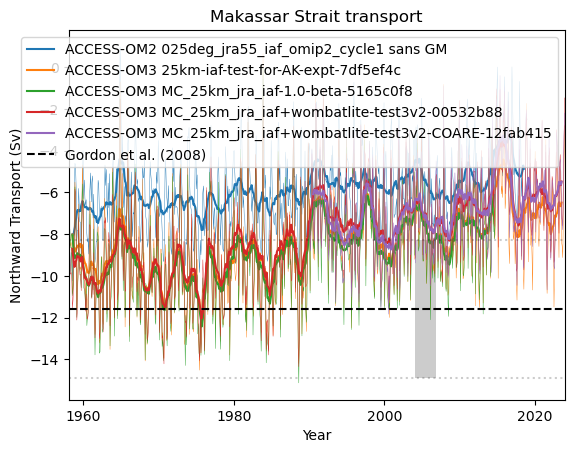

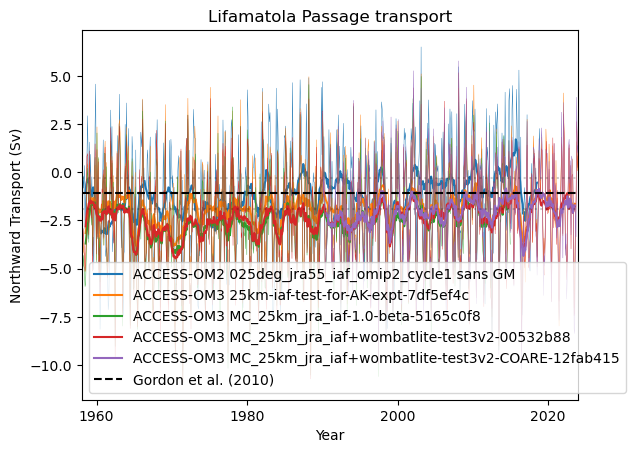

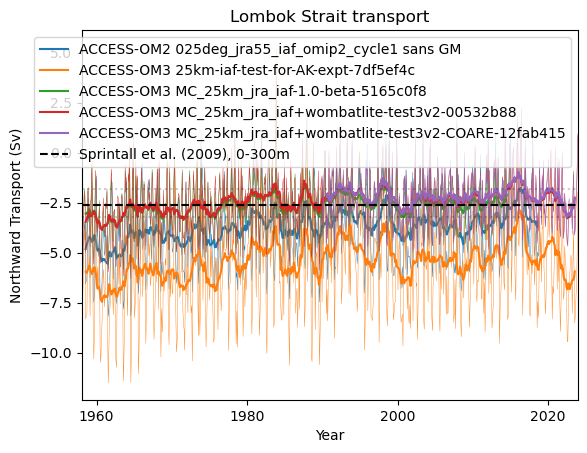

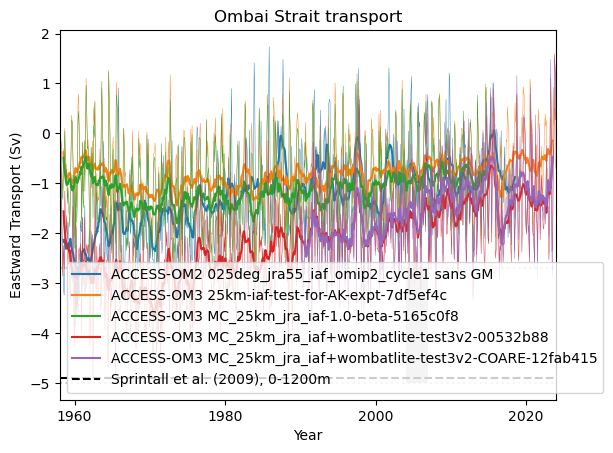

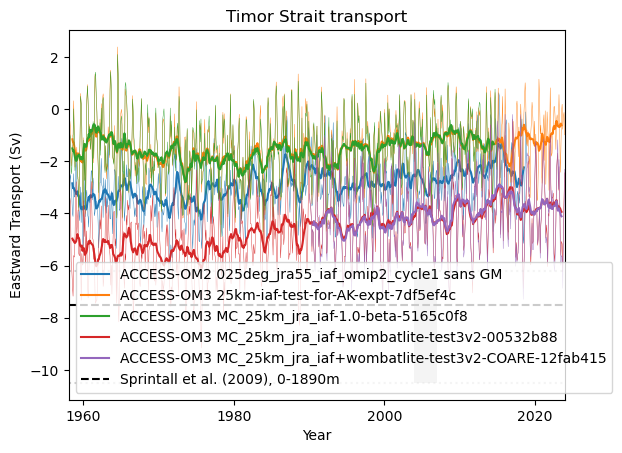

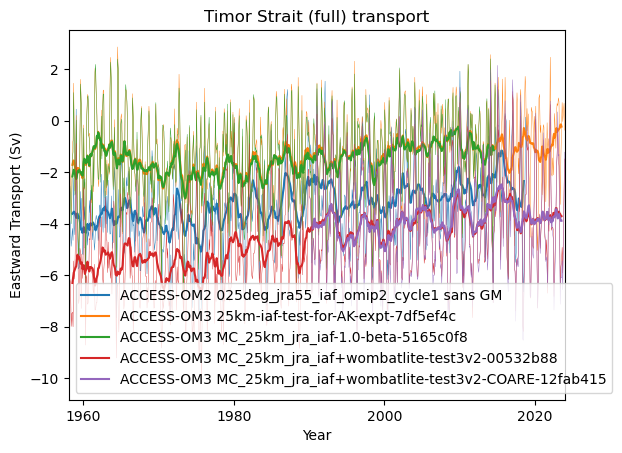

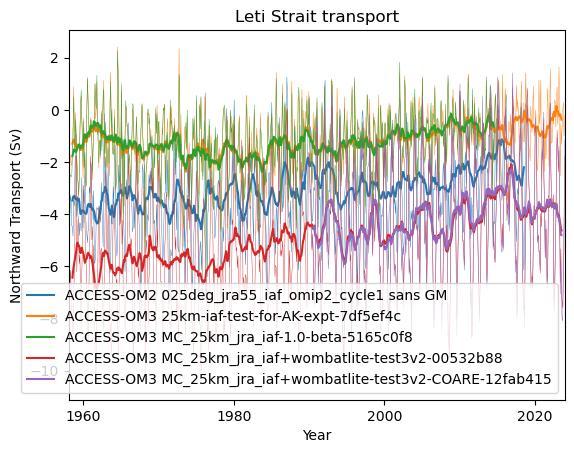

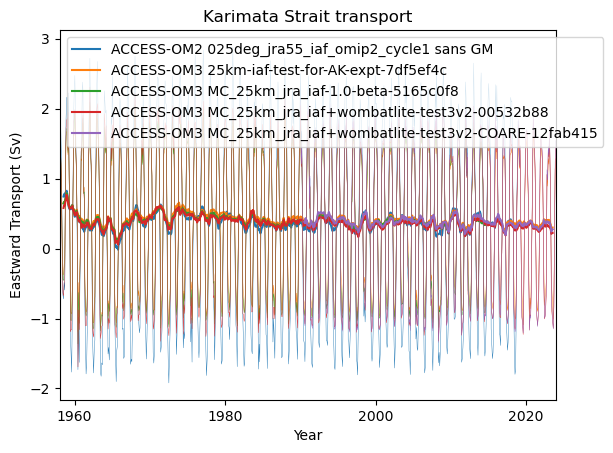

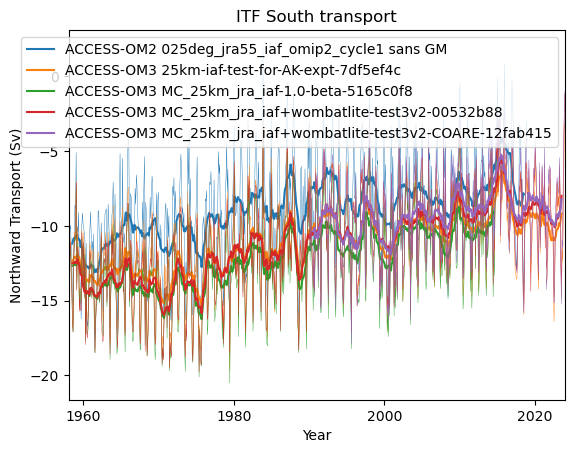

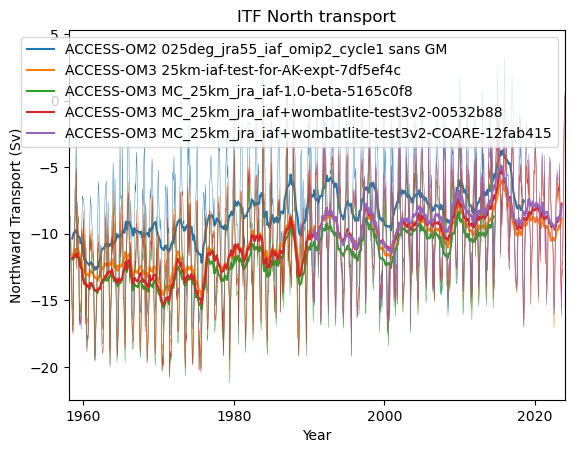

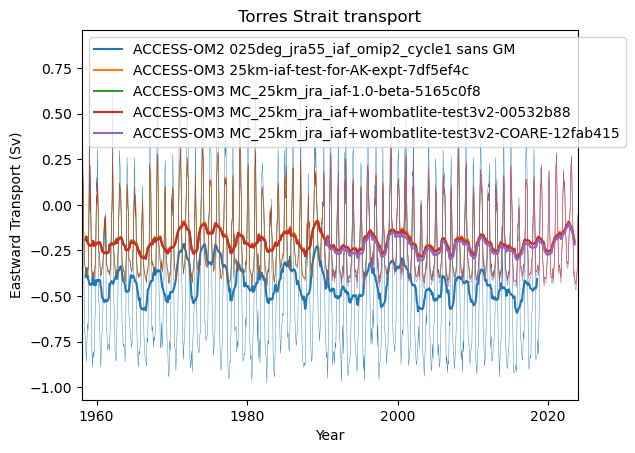

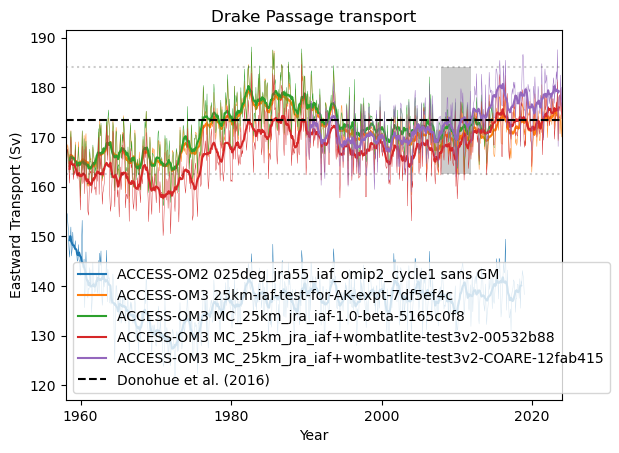

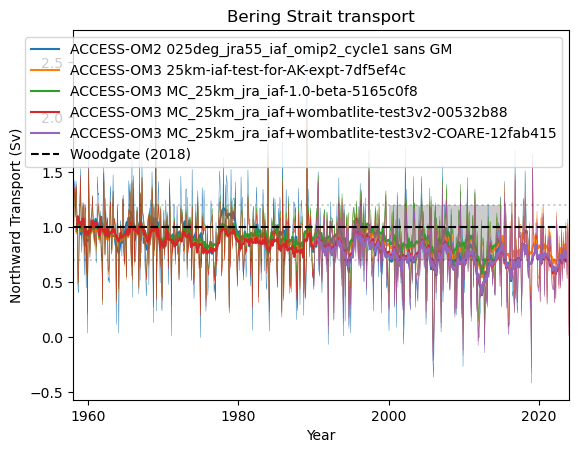

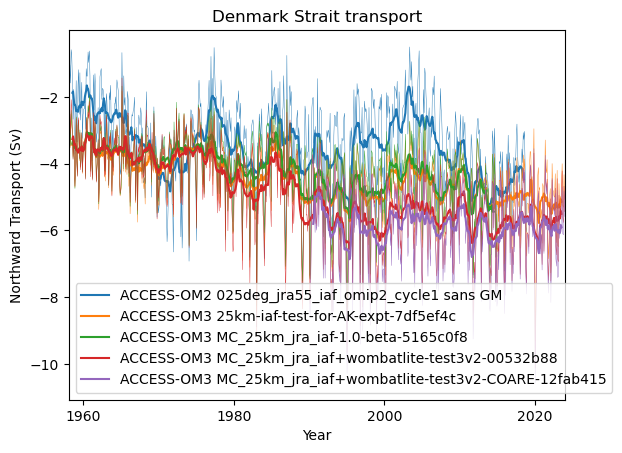

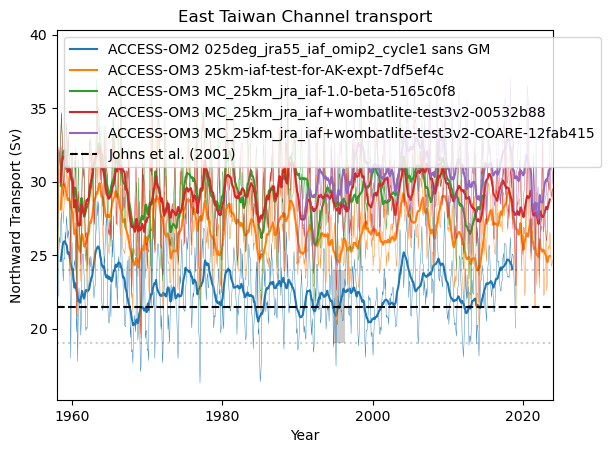

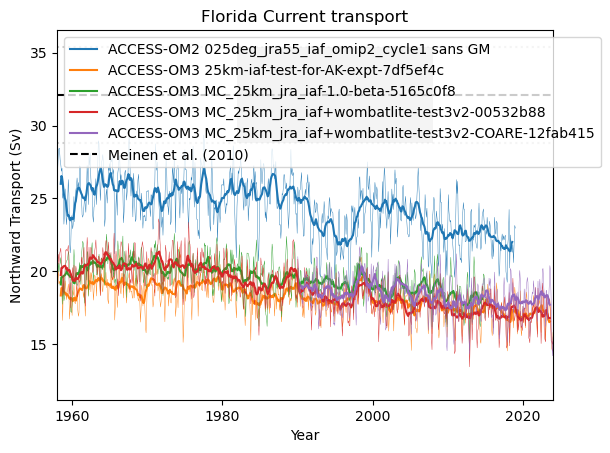

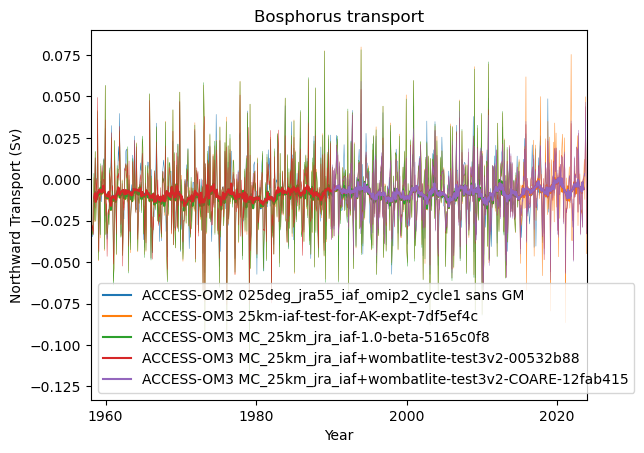

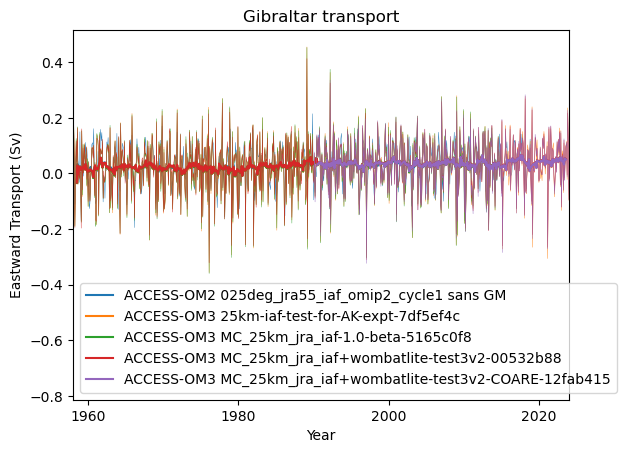

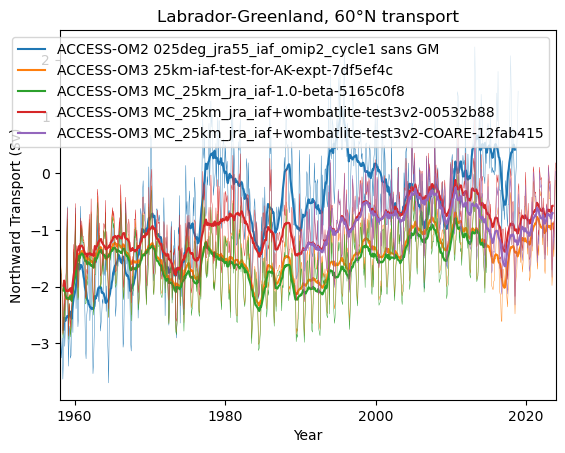

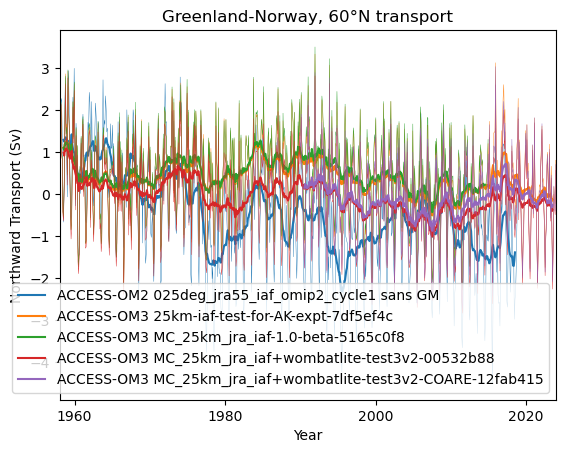

In [38]:
# plot mass transport timeseries (Sv)
# BUG: OM2 GM and submeso transport neglected!

TransTable = [f'{timeslice.start.strftime("%Y-%m-%d")} - {timeslice.stop.strftime("%Y-%m-%d")} mean']
TransTable.append('| Strait | OM2 | ' + ' | '.join(['OM3 '+n for n in datastores]) + ' | Obs |')
TransTable.append('| ------ | --: | ' + ' | '.join(['--:'    for n in datastores]) + ' | --: |')

for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
    plt.figure()

    if strait in om2straits['025deg']:
        (xmin, xmax, ymin, ymax) = om2straits['025deg'][strait]
        if xmin == xmax:
            trans = tx_trans_int_z.tx_trans_int_z.sel(xu_ocean=xmin, method='nearest').sel(yt_ocean=slice(ymin, ymax)).sum('yt_ocean')
        elif ymin == ymax:
            trans = ty_trans_int_z.ty_trans_int_z.sel(xt_ocean=slice(xmin, xmax)).sel(yu_ocean=ymin, method='nearest').sum('xt_ocean')
        else:
            raise ValueError('Transports are computed only along lines of either constant latitude or longitude')
        trans = trans/1e6/1035  # convert to Sv, rho0 = 1035.0
        # trans = trans.sel(time=timeslice)
        trans.plot(linewidth=0.3)
        trans.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM2 {om2exptname} sans GM", linewidth=1.5, color=plt.gca().lines[-1].get_color())
        om2transmeanval = trans.sel(time=timeslice).mean('time').values
        om2transmean = f'{om2transmeanval:.2f}'
    else:
        om2transmean = ' -- '

    transmeans = []
    for expt in datastores:
        if xmin == xmax:
            trans = om3vars['umo_2d'][expt].umo_2d.sel(xq=xmin, method='nearest').sel(yh=slice(ymin, ymax)).sum('yh')
            direction = 'Eastward'
        elif ymin == ymax:
            trans = om3vars['vmo_2d'][expt].vmo_2d.sel(xh=slice(xmin, xmax)).sel(yq=ymin, method='nearest').sum('xh')
            direction = 'Northward'
        else:
            raise ValueError('Transports are computed only along lines of either constant latitude or longitude')
        trans = trans/1e6/1035  # convert to Sv, RHO_0 = 1035.0
        trans.plot(linewidth=0.3)
        trans.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM3 {expt}", linewidth=1.5, color=plt.gca().lines[-1].get_color())
        transmeanval = trans.sel(time=timeslice).mean('time').values
        transmeans.append(f'{transmeanval:.2f}')
    
    plt.autoscale(enable=True, axis='x', tight=True)

    if strait in obs:
        for ref, d in obs[strait].items():
            if 'depth' in d:
                depths = f", {str(d['depth'][0])}-{str(d['depth'][1])}m"
            else:
                depths = ""
            plt.plot(plt.gca().get_xlim(), [d['value'], d['value']], 'k--', label=f"{ref}{depths}",)
            plt.plot(plt.gca().get_xlim(), [d['hi'], d['hi']], 'k:', alpha=0.2)
            plt.plot(plt.gca().get_xlim(), [d['lo'], d['lo']], 'k:', alpha=0.2)
            plt.gca().fill_between(d['time'],
                                   [d['hi'], d['hi']],
                                   [d['lo'], d['lo']],
                                   color='black', edgecolor=None, alpha=0.2)
            obstransval = d['value']
            obstrans = f'{obstransval:.2f}'
    else:
        obstrans = ' -- '

    plt.title(f"{strait} transport")
    plt.xlabel('Year')
    plt.ylabel(f'{direction} Transport (Sv)')
    plt.legend(fontsize=10)

    mkmd.savefig(plt.gcf(), "Strait Transports", f"{strait} transport. [GitHub issue: Drake Passage transport](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/1)")

    # Markdown table - note that this assumes a consistent ordering in dict lookup so requires Python 3.7 or later
    # cb: would be safer here to use a ordered dictionary?
    TransTable.append(f'| {strait} | {om2transmean} | ' + ' | '.join(transmeans) + f' | {obstrans} |')

for trans in TransTable:
    print(trans)

1993-12-16 - 2023-12-16 mean
| Strait | OM2 | OM3 25km-iaf-test-for-AK-expt-7df5ef4c | OM3 MC_25km_jra_iaf-1.0-beta-5165c0f8 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-00532b88 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415 | Obs |
| ------ | --: | --: | --: | --: | --: | --: |
| Makassar Strait | -5.31 | -7.45 | -7.89 | -6.71 | -6.72 | -11.60 |
| Lifamatola Passage | -0.83 | -1.72 | -2.24 | -2.11 | -1.98 | -1.10 |
| Lombok Strait | -3.45 | -5.20 | -2.52 | -2.24 | -2.19 | -2.60 |
| Ombai Strait | -0.93 | -0.67 | -0.93 | -1.59 | -1.45 | -4.90 |
| Timor Strait | -2.58 | -1.26 | -1.31 | -3.98 | -3.98 | -7.50 |
| Timor Strait (full) | -2.79 | -1.04 | -1.13 | -3.87 | -3.87 |  --  |
| Leti Strait | -2.62 | -0.84 | -0.91 | -4.18 | -4.16 |  --  |
| Karimata Strait | 0.35 | 0.39 | 0.37 | 0.34 | 0.37 |  --  |
| ITF South | -7.79 | -9.87 | -10.78 | -9.37 | -9.11 |  --  |
| ITF North | -7.40 | -9.45 | -10.38 | -9.00 | -8.70 |  --  |
| Torres Strait | -0.45 | -0.21 | -0.21 | -0.21 | -0.23 | 

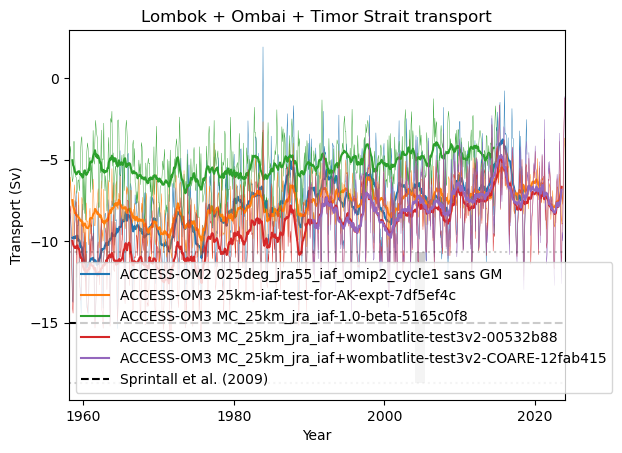

In [39]:
# plot Lombok + Ombai + Timor Strait mass transport timeseries (Sv)
# BUG: OM2 GM and submeso transport neglected!
OM2total  = 0
OM3totals = dict()
transmeans = []

for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
    if strait in [
        'Lombok Strait',
        'Ombai Strait',
        'Timor Strait'
    ]:
        if strait not in om2straits['025deg']:
            raise KeyError(f"{strait} not in om2straits['025deg']")
        (xmin, xmax, ymin, ymax) = om2straits['025deg'][strait]
        if xmin == xmax:
            trans = tx_trans_int_z.tx_trans_int_z.sel(xu_ocean=xmin, method='nearest').sel(yt_ocean=slice(ymin, ymax)).sum('yt_ocean')
        elif ymin == ymax:
            trans = ty_trans_int_z.ty_trans_int_z.sel(xt_ocean=slice(xmin, xmax)).sel(yu_ocean=ymin, method='nearest').sum('xt_ocean')
        OM2total += trans/1e6/1035  # convert to Sv, rho0 = 1035.0
            
        for expt in datastores:
            if xmin == xmax:
                trans = om3vars['umo_2d'][expt].umo_2d.sel(xq=xmin, method='nearest').sel(yh=slice(ymin, ymax)).sum('yh')
            elif ymin == ymax:
                trans = om3vars['vmo_2d'][expt].vmo_2d.sel(xh=slice(xmin, xmax)).sel(yq=ymin, method='nearest').sum('xh')
            try:
                OM3totals[expt] = OM3totals[expt] + trans/1e6/1035  # convert to Sv, RHO_0 = 1035.0
            except KeyError:
                OM3totals[expt] = trans/1e6/1035  # convert to Sv, RHO_0 = 1035.0

plt.figure()

OM2total.plot(linewidth=0.3)
OM2total.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM2 {om2exptname} sans GM", linewidth=1.5, color=plt.gca().lines[-1].get_color())
om2transmean = OM2total.sel(time=timeslice).mean('time').values

for expt, OM3total in OM3totals.items():
    OM3total.plot(linewidth=0.3)
    OM3total.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM3 {expt}", linewidth=1.5, color=plt.gca().lines[-1].get_color())
    transmeanval = OM3total.sel(time=timeslice).mean('time').values
    transmeans.append(f'{transmeanval:.2f}')

plt.autoscale(enable=True, axis='x', tight=True)

# Plot obs values (Sv) from Sprintall et al 2009 table 1
obstrans = -15.0
hi = -10.7
lo = -18.7
plt.plot(plt.gca().get_xlim(), [obstrans, obstrans], 'k--', label="Sprintall et al. (2009)")
plt.plot(plt.gca().get_xlim(), [hi, hi], 'k:', alpha=0.2)
plt.plot(plt.gca().get_xlim(), [lo, lo], 'k:', alpha=0.2)
plt.gca().fill_between([date(2004, 1, 10), date(2005, 6, 15)], # use Lombok dates (narrowest range)
                       [hi, hi],
                       [lo, lo],
                       color='black', edgecolor=None, alpha=0.2)

plt.title(f"Lombok + Ombai + Timor Strait transport")
plt.xlabel('Year')
plt.ylabel(f'Transport (Sv)')
plt.legend(fontsize=10)

mkmd.savefig(plt.gcf(), "Strait Transports", "Lombok + Ombai + Timor Strait transport. [GitHub issue: Indonesian straits](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/16)")

# Markdown table - note that this assumes a consistent ordering in dict lookup so requires Python 3.7 or later
TransTable.append(f'| Lombok + Ombai + Timor Strait | {om2transmean:.2f} | ' + ' | '.join(transmeans) + f' | {obstrans} |')
for trans in TransTable:
    print(trans)

1993-12-16 - 2023-12-16 mean
| Strait | OM2 | OM3 25km-iaf-test-for-AK-expt-7df5ef4c | OM3 MC_25km_jra_iaf-1.0-beta-5165c0f8 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-00532b88 | OM3 MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415 | Obs |
| ------ | --: | --: | --: | --: | --: | --: |
| Makassar Strait | -5.31 | -7.45 | -7.89 | -6.71 | -6.72 | -11.60 |
| Lifamatola Passage | -0.83 | -1.72 | -2.24 | -2.11 | -1.98 | -1.10 |
| Lombok Strait | -3.45 | -5.20 | -2.52 | -2.24 | -2.19 | -2.60 |
| Ombai Strait | -0.93 | -0.67 | -0.93 | -1.59 | -1.45 | -4.90 |
| Timor Strait | -2.58 | -1.26 | -1.31 | -3.98 | -3.98 | -7.50 |
| Timor Strait (full) | -2.79 | -1.04 | -1.13 | -3.87 | -3.87 |  --  |
| Leti Strait | -2.62 | -0.84 | -0.91 | -4.18 | -4.16 |  --  |
| Karimata Strait | 0.35 | 0.39 | 0.37 | 0.34 | 0.37 |  --  |
| ITF South | -7.79 | -9.87 | -10.78 | -9.37 | -9.11 |  --  |
| ITF North | -7.40 | -9.45 | -10.38 | -9.00 | -8.70 |  --  |
| Torres Strait | -0.45 | -0.21 | -0.21 | -0.21 | -0.23 | 

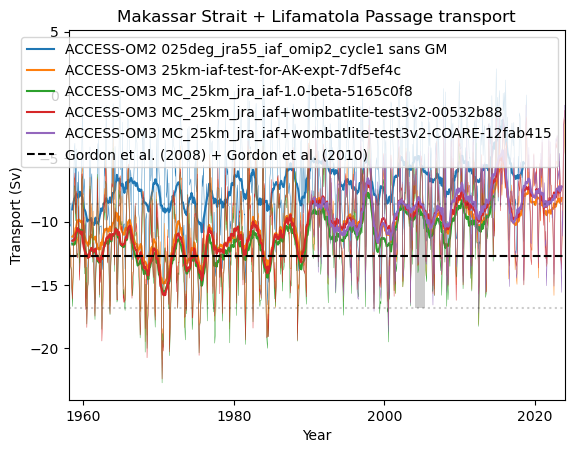

In [40]:
# plot Makassar Strait + Lifamatola Passage mass transport timeseries (Sv)
# BUG: OM2 GM and submeso transport neglected!
OM2total  = 0
OM3totals = dict()
transmeans = []
for strait, (xmin, xmax, ymin, ymax) in om3straits['25km'].items():
    if strait in [
        'Makassar Strait',
        'Lifamatola Passage'
    ]:
        if strait not in om2straits['025deg']:
            raise KeyError(f"{strait} not in om2straits['025deg']")
        (xmin, xmax, ymin, ymax) = om2straits['025deg'][strait]
        if xmin == xmax:
            trans = tx_trans_int_z.tx_trans_int_z.sel(xu_ocean=xmin, method='nearest').sel(yt_ocean=slice(ymin, ymax)).sum('yt_ocean')
        elif ymin == ymax:
            trans = ty_trans_int_z.ty_trans_int_z.sel(xt_ocean=slice(xmin, xmax)).sel(yu_ocean=ymin, method='nearest').sum('xt_ocean')
        OM2total += trans/1e6/1035  # convert to Sv, rho0 = 1035.0
            
        for expt in datastores:
            if xmin == xmax:
                trans = om3vars['umo_2d'][expt].umo_2d.sel(xq=xmin, method='nearest').sel(yh=slice(ymin, ymax)).sum('yh')
            elif ymin == ymax:
                trans = om3vars['vmo_2d'][expt].vmo_2d.sel(xh=slice(xmin, xmax)).sel(yq=ymin, method='nearest').sum('xh')
            try:
                OM3totals[expt] = OM3totals[expt] + trans/1e6/1035  # convert to Sv, RHO_0 = 1035.0
            except KeyError:
                OM3totals[expt] = trans/1e6/1035  # convert to Sv, RHO_0 = 1035.0



plt.figure()

OM2total.plot(linewidth=0.3)
OM2total.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM2 {om2exptname} sans GM", linewidth=1.5, color=plt.gca().lines[-1].get_color())
om2transmean = OM2total.sel(time=timeslice).mean('time').values

for expt, OM3total in OM3totals.items():
    OM3total.plot(linewidth=0.3)
    OM3total.rolling(time=12, center=True).mean().plot(label=f"ACCESS-OM3 {expt}", linewidth=1.5, color=plt.gca().lines[-1].get_color())
    transmeanval = OM3total.sel(time=timeslice).mean('time').values
    transmeans.append(f'{transmeanval:.2f}')

plt.autoscale(enable=True, axis='x', tight=True)

# Plot obs values (Sv) from Sprintall et al 2009 table 1
obstrans = -15.0
hi = -10.7
lo = -18.7
obstrans = obs['Makassar Strait']['Gordon et al. (2008)']['value'] + obs['Lifamatola Passage']['Gordon et al. (2010)']['value']
hi =       obs['Makassar Strait']['Gordon et al. (2008)']['hi']    + obs['Lifamatola Passage']['Gordon et al. (2010)']['hi']
lo =       obs['Makassar Strait']['Gordon et al. (2008)']['lo']    + obs['Lifamatola Passage']['Gordon et al. (2010)']['lo']
plt.plot(plt.gca().get_xlim(), [obstrans, obstrans], 'k--', label="Gordon et al. (2008) + Gordon et al. (2010)")
plt.plot(plt.gca().get_xlim(), [hi, hi], 'k:', alpha=0.2)
plt.plot(plt.gca().get_xlim(), [lo, lo], 'k:', alpha=0.2)
plt.gca().fill_between([date(2004, 1, 10), date(2005, 6, 15)], # use Lombok dates (narrowest range)
                       [hi, hi],
                       [lo, lo],
                       color='black', edgecolor=None, alpha=0.2)

plt.title(f"Makassar Strait + Lifamatola Passage transport")
plt.xlabel('Year')
plt.ylabel(f'Transport (Sv)')
plt.legend(fontsize=10)

mkmd.savefig(plt.gcf(), "Strait Transports", "Makassar Strait + Lifamatola Passage transport. [GitHub issue: Indonesian straits](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/16)")

# Markdown table - note that this assumes a consistent ordering in dict lookup so requires Python 3.7 or later
TransTable.append(f'| Makassar Strait + Lifamatola Passage | {om2transmean:.2f} | ' + ' | '.join(transmeans) + f' | {obstrans} |')
for trans in TransTable:
    print(trans)

mkmd.table("Strait Transports", table=TransTable)

In [41]:
client.close()